# Inicialização

## Import de bibliotecas

In [67]:
import os
import pandas as pd
import numpy as np
import collections
import seaborn as sns
import joblib
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
from pprint import pprint

# from google.colab import drive

from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.transforms import Bbox
from matplotlib.ticker import MaxNLocator

from sklearn import svm, tree
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

from sklearn.model_selection import cross_val_score, cross_val_predict, train_test_split, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score,accuracy_score,roc_curve,\
classification_report,confusion_matrix,auc
from sklearn.preprocessing import label_binarize

pd.set_option('max_colwidth', 800)

## Setup de plotagem de gráficos

In [68]:
rotas = {
    1: { 'cor': '#00bf63', 'nome': 'Verde' },
    2: { 'cor': '#ff3131', 'nome': 'Vermelho' },
    3: { 'cor': '#2440f7', 'nome': 'Azul' },
    4: { 'cor': '#ffd735', 'nome': 'Amarelo' }
}

# plots saving/showing configurations
save_file_flag=True
show_IV_plot=True

In [69]:
# function to return key for any value

def get_key(val,mydict):
	for key, value in mydict.items():
		if val == value:
			return key

def count_label(labels,labels_dic):
    label_buf=collections.Counter(labels)
    counted_labels_dic={get_key(key1,labels_dic):value1 for key1,value1 in label_buf.items()}
    return counted_labels_dic

In [70]:
def lines_plot(df_i,save_path,title_str='',y_label='',x_label='',save_file=''):

    fig=plt.figure()
    for key in df_i.keys():
        plt.plot(np.arange(len(df_i[key])),df_i[key],marker='x',label=key)
    plt.xticks(np.arange(len(df_i[key])),list(map(str,np.arange(1,len(df_i[key])+1,1))))
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title_str)
    #plt.legend(loc="best",bbox_to_anchor=(0.6, 0.4), ncol=2)
    plt.legend(loc="best")
    plt.grid()
    if save_file:
         plt.savefig(f"{os.path.join(save_path, save_file)}", dpi=300, format='pdf', bbox_inches='tight')
    plt.show()


def create_boxplot(valu_vec,save_path,date_set,title_str='',y_label='',x_label='',save_file=''):

    meanpointprops = dict(marker='+', markeredgecolor='darkgoldenrod',markerfacecolor='red')
    medianprops = dict(linestyle='-', linewidth=1, color='red')

    pltbx=plt.boxplot(valu_vec, showfliers=False,labels=date_set,meanprops=meanpointprops,medianprops=medianprops,
            showmeans=True,patch_artist=True)
    means_vals = [item.get_ydata()[0] for item in pltbx['means']]
    plt.setp(pltbx['boxes'], color='blue',facecolor='white')
    plt.title("%s"%title_str)
    #plt.ylim(0,10)
    plt.ylabel(y_label)
    plt.xlabel(x_label)
    #plt.xticks(rotation = 45)
    legend_elements = [Line2D([0], [0], color='red', lw=1, label='Median'),
                    Line2D([0], [0], color='darkgoldenrod',marker='+',label='Mean'),
                  Line2D([0], [0], color='blue', lw=1, label='25%-75%'),
                   Line2D([0], [0], color='black', lw=1, label='9%-91%')]
    plt.legend(handles=legend_elements,loc='best',  fancybox=True, framealpha=1)
    plt.grid()
    if save_file:
         plt.savefig(f"{os.path.join(save_path, save_file)}", dpi=300, format='pdf', bbox_inches='tight')
    plt.show()
    return means_vals

#####################################################################################################################

def call_compute_color_position(ax,confusion_mat):
    for i in range(confusion_mat.shape[0]):
        for j in range(confusion_mat.shape[1]):
            ax.text(x=j, y=i,s=confusion_mat[i, j], va='center', ha='center', size='large')
    ax.tick_params(top=False, bottom=True,labeltop=False, labelbottom=True)
    #ax.tick_params(top=True, bottom=False,labeltop=True, labelbottom=False)
    return ax

def plot_matrix(conf_mat,class_labels,classifier,title_str='',save_path='', file_prefix='mc'):

    fig = plt.figure()
    axes = fig.add_subplot(111)
    cax=axes.matshow(conf_mat, cmap=plt.cm.YlGnBu, alpha=0.8)
    fig.colorbar(cax)
    axes=call_compute_color_position(axes,conf_mat)
    axes.set_xlabel('Predictions')
    axes.set_ylabel('Actuals')
    axes.set_title(f'{title_str}',fontsize=10)
    axes.set_xticklabels([''] + class_labels)
    axes.set_yticklabels([''] + class_labels)
    if save_path and file_prefix:
        os.makedirs(save_path, exist_ok=True)
        file_to_save=f"{file_prefix}_{classifier}.png"
        plt.savefig(f"{os.path.join(save_path, file_to_save)}", dpi=300, bbox_inches='tight')
    plt.show()

In [71]:
def plot_roc_curve(y_test_binarized, class_labels, classifier, y_pred_proba, title_str='', save_path='', save_file='', binary_classification=True):
    n_class = len(class_labels)

    if binary_classification:
        unique_classes = np.unique(y_test)
        y_test_binary = np.where(y_test == unique_classes[0], 0, 1)

        y_score = y_pred_proba[:, 1]

        fpr, tpr, _ = roc_curve(y_test_binary, y_score)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, linewidth=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    else:
        unique_classes = np.unique(y_test)
        y_test_binarized = label_binarize(y_test, classes=unique_classes)

        if y_test_binarized.shape[1] == 1:
            y_test_binarized = np.hstack([1 - y_test_binarized, y_test_binarized])

        fpr = {}
        tpr = {}
        roc_auc = {}

        for i in range(n_class):
            fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
            plt.plot(fpr[i], tpr[i], linestyle='--', linewidth=2,
                    label=f'{class_labels[i]} vs Rest (AUC = {roc_auc[i]:.3f})')

        fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), y_pred_proba.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_class)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_class):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= n_class

        fpr["macro"] = all_fpr
        tpr["macro"] = mean_tpr
        roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

        # Plotar médias
        plt.plot(fpr["micro"], tpr["micro"],
                label=f'micro-average (AUC = {roc_auc["micro"]:.3f})',
                color="deeppink", linestyle="-.", linewidth=3)

        plt.plot(fpr["macro"], tpr["macro"],
                label=f'macro-average (AUC = {roc_auc["macro"]:.3f})',
                color="navy", linestyle="-.", linewidth=3)

    plt.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1.5,
            label='Random Classifier')

    # Configurações do gráfico
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(title_str if title_str else f'{classifier} - ROC Curve', fontsize=14)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)

    # Salvar se necessário
    if save_file and save_path:
        file_to_save = f"{save_file}_{classifier}.pdf"
        full_path = os.path.join(save_path, file_to_save)
        plt.savefig(full_path, dpi=300, bbox_inches='tight')
        print(f"Gráfico salvo em: {full_path}")

    plt.show()
    plt.close()

In [72]:
def full_extent(ax, pad=0.0):
    """Get the full extent of an axes, including axes labels, tick labels, and
    titles."""
    # For text objects, we need to draw the figure first, otherwise the extents
    # are undefined.
    ax.figure.canvas.draw()
    items = ax.get_xticklabels() + ax.get_yticklabels()
#    items += [ax, ax.title, ax.xaxis.label, ax.yaxis.label]
    items += [ax, ax.title]
    bbox = Bbox.union([item.get_window_extent() for item in items])

    return bbox.expanded(0.98 + pad, 1.12 + pad)



def plot_Prob_Dist_OvR(class_labels,classifier,y_pred_proba,y_target,title_str='',save_path='',save_file=''):
    fig=plt.figure(figsize = (15, 4))
    bins = [i/20 for i in range(20)] + [1]
    roc_auc_ovr = {}
    prob_class_dic={}
    i=0
    for key,value in class_labels.items():
        class_binary = [1 if y == value else 0 for y in y_target]

        # Prepares an auxiliar dataframe to help with the plots
        prob_class_dic['class'] = class_binary
        prob_class_dic['prob'] = y_pred_proba[:, i]
        df_aux=pd.DataFrame(prob_class_dic)
        df_aux = df_aux.reset_index(drop = True)


        # Plots the probability distribution for the class and the rest
        ax = plt.subplot(1, 4, i+1)
        #fig=sns.histplot(x='prob',data = df_aux, color = 'b', hue = 'class',ax = ax, bins = bins).get_figure()
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        sns.histplot(x='prob',data = df_aux, color = 'b', hue = 'class',ax = ax, bins = bins)
        #ax.set_title(value)
        ax.legend([f"Class: {key}", "Rest"])
        ax.set_xlabel(f"P(x = {key})")
        i=i+1
        if save_file:
            extent = full_extent(ax).transformed(fig.dpi_scale_trans.inverted())
            file_to_save=f"{save_file}_{classifier}_{key}.pdf"
            fig.savefig(f"{os.path.join(save_path, file_to_save)}", dpi=350,bbox_inches=extent)

    plt.tight_layout()
    plt.show()

## Ambiente de avaliação dos modelos

In [73]:
Path('models').mkdir(exist_ok=True)

In [74]:
# Definir modelos
models = [
    ('LogisticRegression', LogisticRegression(max_iter=1000)),
    ('KNeighbors', KNeighborsClassifier()),
    ('SVC', svm.SVC(probability=True)),
    ('DecisionTree', tree.DecisionTreeClassifier()),
    ('ExtraTrees', ExtraTreesClassifier()),
    ('RandomForest', RandomForestClassifier()),
    ('GaussianNB', GaussianNB())
]

pipelines = {}

for model_name, model in models:
        pipelines[model_name] = Pipeline(steps=[('classifier', model)])

In [75]:
def model_cross_validation(X_train, y_train, pipelines, folds=5, binary_classification=True):
    """
    Realiza validação cruzada nos dados de TREINO usando Stratified K-Fold
    Garante que cada dobra (fold) mantenha a proporção de classes
    """

    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

    cv_results = []

    print("="*80)
    print("VALIDAÇÃO CRUZADA NO CONJUNTO DE TREINO (Stratified K-Fold)")
    print("="*80)

    for model_name, pipeline in pipelines.items():
        try:
            scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='accuracy')
            y_pred = cross_val_predict(pipeline, X_train, y_train, cv=skf, method='predict')
            y_predproba = cross_val_predict(pipeline, X_train, y_train, cv=skf, method='predict_proba')

            precision = precision_score(y_train, y_pred, average='macro', zero_division=0)
            recall = recall_score(y_train, y_pred, average='macro', zero_division=0)
            f1 = f1_score(y_train, y_pred, average='macro', zero_division=0)

            cv_results.append({
                'Model': model_name,
                'Acc_mean': f"{scores.mean():.4f}",
                'Acc_std': f"{scores.std():.4f}",
                'Precision': f"{precision:.4f}",
                'Recall': f"{recall:.4f}",
                'F1-Score': f"{f1:.4f}"
            })

            print(f"{model_name:20s} | Acc: {scores.mean():.4f} ± {scores.std():.4f}")

        except Exception as e:
            print(f"{model_name:20s} | ERRO: {str(e)}")
            cv_results.append({
                'Model': model_name,
                'Acc_mean': 'ERRO',
                'Acc_std': 'ERRO',
                'Precision': 'ERRO',
                'Recall': 'ERRO',
                'F1-Score': 'ERRO'
            })

    cv_df = pd.DataFrame(cv_results)
    return cv_df

In [76]:
def model_train(X_train, y_train, pipelines):
    # Treinar pipeline completo para uso posterior com dados de teste (não vistos)
    trained_pipelines = {}

    for model_name, pipeline in pipelines.items():
        pipeline.fit(X_train, y_train)
        trained_pipelines[model_name] = pipeline

        joblib.dump(pipeline, f'models/{model_name}.pkl')

    return trained_pipelines

In [88]:
def evaluate_on_test(X_test, y_test, trained_pipelines, class_labels, binary_classification=True, result_path=''):
    # Avalia todos os modelos treinados no conjunto de TESTE

    lines = []

    def log(text=''):
        print(text)
        lines.append(str(text))

    log("="*80)
    log("AVALIAÇÃO NO CONJUNTO DE TESTE (DADOS NÃO VISTOS)")
    log("="*80 + "\n")

    class_labels_str = [str(label) for label in class_labels]
    test_results = []

    for model_name, pipeline in trained_pipelines.items():
        log(f"\n{'─'*80}")
        log(f"Modelo: {model_name}")
        log(f"{'─'*80}")

        try:
            y_pred = pipeline.predict(X_test)
            y_pred_proba = pipeline.predict_proba(X_test)

            accuracy  = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
            recall    = recall_score(y_test, y_pred, average='macro', zero_division=0)
            f1        = f1_score(y_test, y_pred, average='macro', zero_division=0)

            test_results.append({
                'Model': model_name,
                'Accuracy': f"{accuracy:.4f}",
                'Precision': f"{precision:.4f}",
                'Recall': f"{recall:.4f}",
                'F1-Score': f"{f1:.4f}"
            })

            log("\nRelatório de Classificação:")
            log(classification_report(y_test, y_pred,
                                      target_names=class_labels_str,
                                      labels=class_labels,
                                      zero_division=0))

            cm = confusion_matrix(y_test, y_pred, labels=class_labels)
            log("\nMatriz de Confusão:")
            log(cm)

            plot_matrix(cm, class_labels_str, model_name,
                        title_str=f'{model_name} - Conjunto de Teste',
                        save_path=result_path,
                        file_prefix='mc')

        except Exception as e:
            log(f"\nERRO ao avaliar {model_name}: {str(e)}")
            test_results.append({
                'Model': model_name,
                'Accuracy': 'ERRO', 'Precision': 'ERRO',
                'Recall': 'ERRO',   'F1-Score': 'ERRO'
            })

    log("\n" + "="*80)
    log("RELATÓRIO RESUMIDO - CONJUNTO DE TESTE")
    log("="*80)

    for result in test_results:
        log(f"{result['Model']:20s} | Acc: {result['Accuracy']}")

    log("="*80 + "\n")

    # Salvar summary.txt na mesma pasta das imagens
    summary_path = os.path.join(result_path, 'summary.txt')
    with open(summary_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines))

    test_df = pd.DataFrame(test_results)
    return test_df

In [91]:
def compare_train_test_performance(cv_df, test_df, result_path='./results'):
    """
    Compara performance entre validação cruzada (treino) e teste
    Lida com modelos que falharam (valores 'ERRO' ou 'N/A')
    """
    print("\n" + "="*80)
    print("COMPARAÇÃO: VALIDAÇÃO CRUZADA vs TESTE")
    print("="*80 + "\n")

    comparison = pd.DataFrame({
        'Model': cv_df['Model'],
        'CV_Accuracy': cv_df['Acc_mean'],
        'Test_Accuracy': test_df['Accuracy']
    })

    print(comparison.to_string(index=False))

    # Filtrar apenas modelos que funcionaram (sem 'ERRO' ou 'N/A')
    def is_valid_value(val):
        """Verifica se o valor é numérico válido"""
        if pd.isna(val):
            return False
        if isinstance(val, str) and val.upper() in ['ERRO', 'N/A', 'NAN']:
            return False
        try:
            float(val)
            return True
        except (ValueError, TypeError):
            return False

    # Criar máscara para linhas válidas
    valid_mask = (
        comparison['CV_Accuracy'].apply(is_valid_value) &
        comparison['Test_Accuracy'].apply(is_valid_value)
    )

    comparison_valid = comparison[valid_mask].copy()
    comparison_invalid = comparison[~valid_mask].copy()

    # Informar sobre modelos excluídos
    if len(comparison_invalid) > 0:
        print(f"\n⚠️  {len(comparison_invalid)} modelo(s) excluído(s) do gráfico por conter erros:")
        for model in comparison_invalid['Model']:
            print(f"   - {model}")

    # Verificar se há modelos válidos para plotar
    if len(comparison_valid) == 0:
        print("\nERRO: Nenhum modelo válido para comparação!")
        return comparison

    # Converter para float
    comparison_valid['CV_Accuracy'] = comparison_valid['CV_Accuracy'].astype(float)
    comparison_valid['Test_Accuracy'] = comparison_valid['Test_Accuracy'].astype(float)

    # Plotar comparação
    fig, ax = plt.subplots(figsize=(14, 5))

    models = comparison_valid['Model']
    x = np.arange(len(models))
    width = 0.35

    # Acurácia
    cv_acc = comparison_valid['CV_Accuracy'].values
    test_acc = comparison_valid['Test_Accuracy'].values

    bars1 = ax.bar(x - width/2, cv_acc, width, label='Validação Cruzada', alpha=0.8, color='skyblue')
    bars2 = ax.bar(x + width/2, test_acc, width, label='Teste', alpha=0.8, color='coral')

    # Adicionar valores nas barras
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xlabel('Modelo', fontsize=11)
    ax.set_ylabel('Acurácia', fontsize=11)
    ax.set_title('Comparação de Acurácia', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
    ax.legend(loc='best')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.1])

    plt.tight_layout()

    save_path = f"{result_path}/comparacao_treino_vs_teste.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

    # Análise de overfitting
    print("\n" + "="*80)
    print("ANÁLISE DE OVERFITTING")
    print("="*80)

    for idx, row in comparison_valid.iterrows():
        model = row['Model']
        cv_acc = row['CV_Accuracy']
        test_acc = row['Test_Accuracy']
        diff = cv_acc - test_acc

        print(f"{model:20s} | CV: {cv_acc:.4f} | Test: {test_acc:.4f} | Diff: {diff:+.4f}")

    return comparison

# Carregamento do dataset
Atualize os parâmetros para carregar o dataset desejado.

In [79]:
# Se "True", descomente o import do Google Drive e garanta que o pacote esteja instalado no ambiente
TEST_ON_COLAB = False

DATASET_FOLDER = 'datasets'
RESULTS_FOLDER = 'resultados_am'
DATASET = 'D1'

CENARIO = 'Teste'

historico_latencias_csv = 'latencia_rotas_h1_h6.csv' # sempre csv
rotulos_txt = 'rotulos_h1_h6.txt'    # sempre txt

if TEST_ON_COLAB:
    pasta_dataset = f"/content/drive/MyDrive/{DATASET_FOLDER}/{DATASET}"
    drive.mount("/content/drive")
else:
    pasta_dataset = f"{DATASET_FOLDER}/{DATASET}"

pasta_resultados=f"{RESULTS_FOLDER}/Cenario{CENARIO}_{DATASET}"

os.makedirs(pasta_dataset, exist_ok=True)
os.makedirs(pasta_resultados, exist_ok=True)

## Import de Dados

In [80]:
historico_latencias = pd.read_csv(f"{pasta_dataset}/{historico_latencias_csv}")
rotulos = np.loadtxt(f"{pasta_dataset}/{rotulos_txt}", comments='#', dtype=int)

latencia_por_rota = historico_latencias.iloc[:, 1:].values

datetimes = historico_latencias.iloc[:, 0].values
datetimes_dt = pd.to_datetime(datetimes)

temporal_features = np.column_stack([
    datetimes_dt.hour,           # Hora do dia (0-23)
    datetimes_dt.minute,         # Minuto (0-59)
    datetimes_dt.second,         # Segundo (0-59)
    # datetimes_dt.dayofweek,    # Dia da semana (0=Segunda, 6=Domingo) - irrelevante para o conjunto de dados atual
    datetimes_dt.day,            # Dia do mês (1-31)
    datetimes_dt.month,          # Mês (1-12)
    datetimes_dt.year            # Ano
])

print(datetimes[:5], '\n')
print(datetimes_dt[:5], '\n')
print(temporal_features[:5], '\n')
print(latencia_por_rota[:5], '\n')
print(rotulos[:5])

['2025-11-26 11:00:23' '2025-11-26 11:00:24' '2025-11-26 11:00:25'
 '2025-11-26 11:00:26' '2025-11-26 11:00:27'] 

DatetimeIndex(['2025-11-26 11:00:23', '2025-11-26 11:00:24',
               '2025-11-26 11:00:25', '2025-11-26 11:00:26',
               '2025-11-26 11:00:27'],
              dtype='datetime64[ns]', freq=None) 

[[  11    0   23   26   11 2025]
 [  11    0   24   26   11 2025]
 [  11    0   25   26   11 2025]
 [  11    0   26   26   11 2025]
 [  11    0   27   26   11 2025]] 

[[24.96260223 36.65921116 23.16917491 19.72448474]
 [24.1        34.90455225 21.91784083 19.19295738]
 [24.1        35.18569537 22.38142768 19.1036347 ]
 [24.1        35.2        22.4        19.38866208]
 [24.1        35.10500653 22.49605717 19.49606321]] 

[4 4 4 4 4]


In [81]:
X = np.hstack([temporal_features, latencia_por_rota])
y = rotulos

pathIds = list(range(1, latencia_por_rota.shape[1]+1))
n_classes = len(pathIds)

In [82]:
print(f"Shape: {X.shape}")
print("Primeiras linhas:", X[:5])
print(y)

print(pathIds, n_classes)

Shape: (3599, 10)
Primeiras linhas: [[  11.            0.           23.           26.           11.
  2025.           24.96260223   36.65921116   23.16917491   19.72448474]
 [  11.            0.           24.           26.           11.
  2025.           24.1          34.90455225   21.91784083   19.19295738]
 [  11.            0.           25.           26.           11.
  2025.           24.1          35.18569537   22.38142768   19.1036347 ]
 [  11.            0.           26.           26.           11.
  2025.           24.1          35.2          22.4          19.38866208]
 [  11.            0.           27.           26.           11.
  2025.           24.1          35.10500653   22.49605717   19.49606321]]
[4 4 4 ... 4 4 4]
[1, 2, 3, 4] 4


# Análise do dataset

In [45]:
classes = {}

for pathId in pathIds:
    nome = rotas[pathId]["nome"]
    classes[nome] = pathId

print(classes)

{'Verde': 1, 'Vermelho': 2, 'Azul': 3, 'Amarelo': 4}


In [46]:
d = {  'rotulos': pd.Series(rotulos),
	   'latencias': pd.Series(latencia_por_rota.tolist()) }

df = pd.DataFrame(d)

qtd_leituras = df.shape[0]

print("Numero de linhas: ", qtd_leituras)
print("Qtd Rótulos: ", rotulos.shape)
print("Qtd Latências: ", df['latencias'].shape)

print(df['rotulos'].value_counts())

Numero de linhas:  3599
Qtd Rótulos:  (3599,)
Qtd Latências:  (3599,)
rotulos
4    3597
3       2
Name: count, dtype: int64


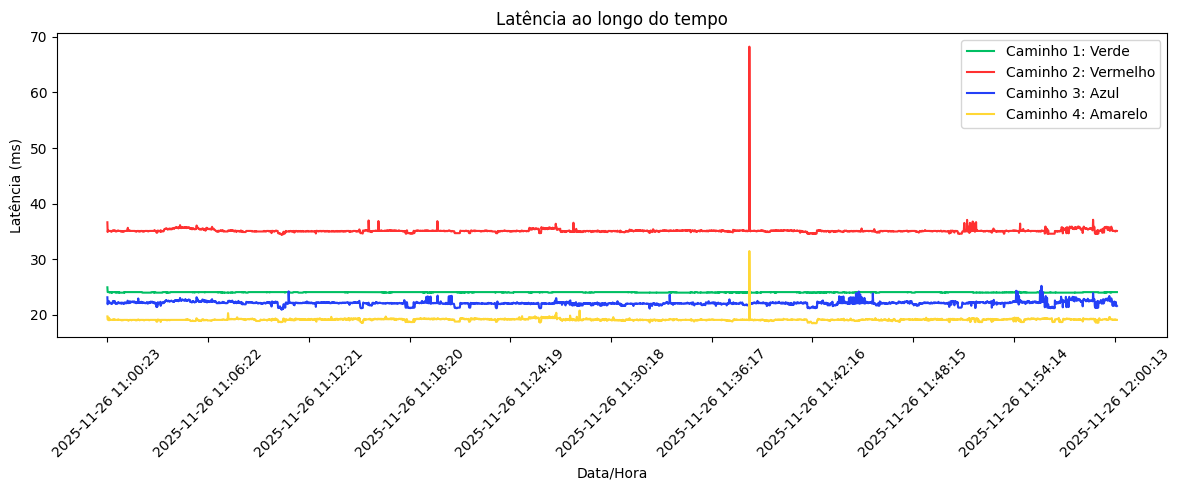

In [47]:
fig = plt.figure(figsize=(12, 5))

for pathId in pathIds:
    propriedades = rotas[pathId]
    nome = propriedades["nome"]
    cor = propriedades["cor"]

    plt.plot(datetimes, latencia_por_rota[:, pathId - 1], label=f'Caminho {pathId}: {nome}', color=cor, linewidth=1.5)

step = max(1, len(datetimes) // 10)  # mostra +- 10 datas no eixo
plt.xticks(datetimes[::step], rotation=45)

plt.legend()
plt.xlabel('Data/Hora')
plt.ylabel('Latência (ms)')
plt.title('Latência ao longo do tempo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Execução do Pipeline

1.   Separação dos dados entre treino e teste (80% : 20%)
2.   Validação cruzada dos modelos com o conjunto de treino, com estratificação (não salva estados do treinamento)
3.   Treinamento dos modelos com o conjunto de treino
4.   Teste dos modelos com o conjunto de teste
5.   Comparação de desempenho entre treino (validação cruzada) e teste



In [83]:
rotulos_dataset = np.unique(y).tolist()
binaryClassification = len(rotulos_dataset) <= 2

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=1234,
                                                    shuffle=True, stratify=None)
print(f"Total de amostras: {len(y)}\n")

print(f"Classes únicas:\t\t{rotulos_dataset}")
print(f'Classes em y_train:\t{np.unique(y_train)}')
print(f'Classes em y_test:\t{np.unique(y_test)}')

print("\nDistribuição das classes:")
print(pd.Series(y).value_counts())

Total de amostras: 3599

Classes únicas:		[3, 4]
Classes em y_train:	[3 4]
Classes em y_test:	[3 4]

Distribuição das classes:
4    3597
3       2
Name: count, dtype: int64


In [84]:
print(len(y_train), len(y_test), len(y_train) + len(y_test))

2879 720 3599


In [ ]:
resultados_cv = model_cross_validation(X_train, y_train, pipelines, folds=5, binary_classification=binaryClassification)

In [86]:
trained_pipelines = model_train(X_train, y_train, pipelines)

In [ ]:
test_results = evaluate_on_test(
    X_test, 
    y_test, 
    trained_pipelines, 
    rotulos_dataset, 
    binary_classification=binaryClassification, 
    result_path=f'{pasta_resultados}'
)

In [ ]:
compare_train_test_performance(resultados_cv, test_results, result_path=f'{pasta_resultados}')

# Testes manuais após o treinamento

Obter cortes dos dados em momentos diferentes, para analisar como o modelo generalizou os diferentes padrões da rede ao longo do tempo.

In [ ]:
historico_latencias_novo = pd.read_csv(f"nova_latencia/60min_streaming_simultaneo/latencia_rotas_h1_h6.csv")
rotulos_novo = np.loadtxt(f"nova_latencia/60min_streaming_simultaneo/labels_h1_h6.txt", comments='#', dtype=int)

different_datetimes = historico_latencias_novo.iloc[:, 0].values
different_datetimes_dt = pd.to_datetime(different_datetimes)

different_temporal_features = np.column_stack([
    different_datetimes_dt.hour,           # Hora do dia (0-23)
    different_datetimes_dt.minute,         # Minuto (0-59)
    different_datetimes_dt.second,         # Segundo (0-59)
    # datetimes_dt.dayofweek,    # Dia da semana (0=Segunda, 6=Domingo) - irrelevante para o conjunto de dados atual
    different_datetimes_dt.day,            # Dia do mês (1-31)
    different_datetimes_dt.month,          # Mês (1-12)
    different_datetimes_dt.year            # Ano
])

different_routes_latency = historico_latencias_novo.iloc[:, 1:].values

X_different = np.hstack([different_temporal_features, different_routes_latency])
y_different = rotulos_novo

pathIds = [1, 2, 3, 4]
n_classes = len(pathIds)
binaryClassification = n_classes <= 2


fig = plt.figure(figsize=(12, 5))

for i in range(n_classes):
    pathId = i + 1

    propriedades = rotas[pathId]
    nome = propriedades["nome"]
    cor = propriedades["cor"]

    plt.plot(different_datetimes, different_routes_latency[:, i], label=f'Caminho {pathId}: {nome}', color=cor, linewidth=1.5)

step = max(1, len(different_datetimes) // 10)  # mostra +- 10 datas no eixo
plt.xticks(different_datetimes[::step], rotation=45)

plt.legend()
plt.xlabel('Data/Hora')
plt.ylabel('Latência (ms)')
plt.title('Latência ao longo do tempo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

test_results = evaluate_on_test(X_different, y_different, trained_pipelines, pathIds, binary_classification=binaryClassification, result_path=f'testes/antiga2nova/4/results')

## Outros testes

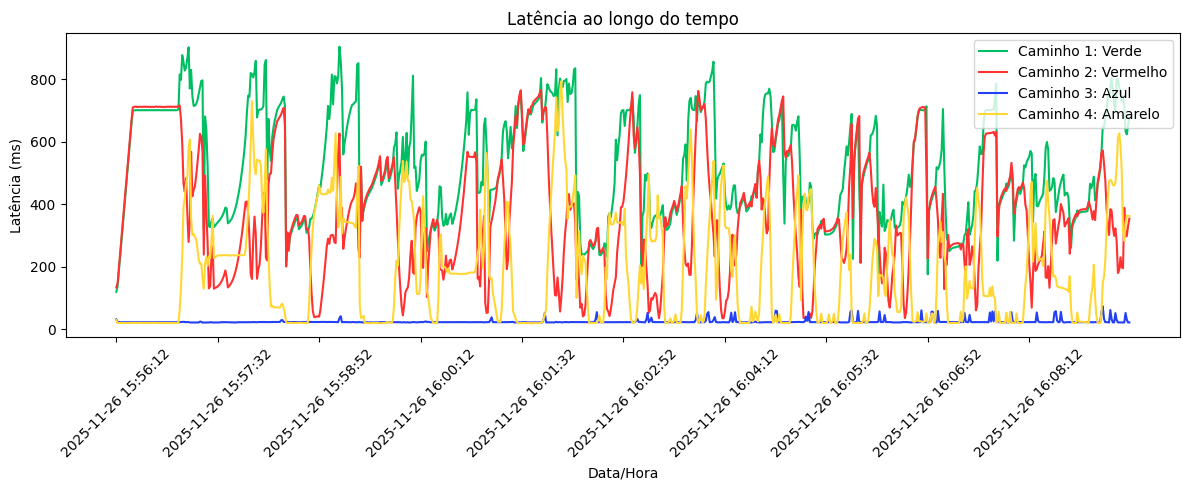

AVALIAÇÃO NO CONJUNTO DE TESTE (DADOS NÃO VISTOS)


────────────────────────────────────────────────────────────────────────────────
Modelo: LogisticRegression
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         2
           3       1.00      1.00      1.00       580
           4       1.00      1.00      1.00       218

    accuracy                           1.00       800
   macro avg       0.50      0.50      0.50       800
weighted avg       1.00      1.00      1.00       800


Matriz de Confusão:
[[  0   0   0   0]
 [  0   0   2   0]
 [  0   0 580   0]
 [  0   0   0 218]]


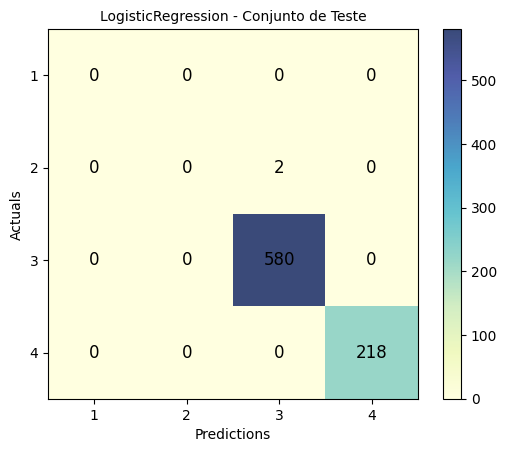


────────────────────────────────────────────────────────────────────────────────
Modelo: KNeighbors
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         2
           3       0.96      0.94      0.95       580
           4       0.86      0.92      0.89       218

    accuracy                           0.93       800
   macro avg       0.46      0.47      0.46       800
weighted avg       0.93      0.93      0.93       800


Matriz de Confusão:
[[  0   0   0   0]
 [  0   0   2   0]
 [  0   0 547  33]
 [  0   0  18 200]]


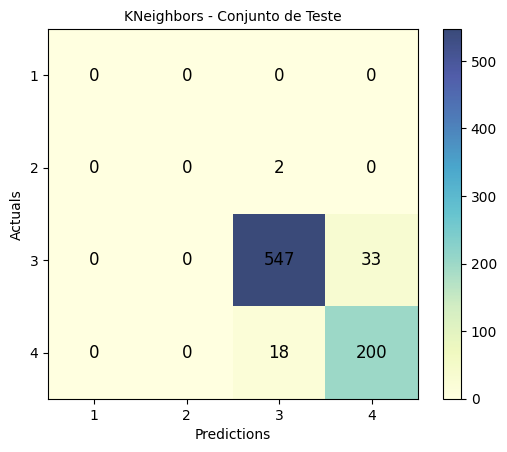


────────────────────────────────────────────────────────────────────────────────
Modelo: SVC
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         2
           3       1.00      0.78      0.88       580
           4       0.64      1.00      0.78       218

    accuracy                           0.84       800
   macro avg       0.41      0.45      0.41       800
weighted avg       0.90      0.84      0.85       800


Matriz de Confusão:
[[  0   0   0   0]
 [  0   0   2   0]
 [  0   0 455 125]
 [  0   0   0 218]]


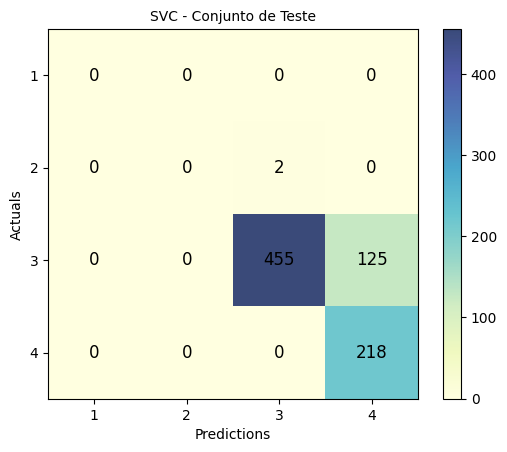


────────────────────────────────────────────────────────────────────────────────
Modelo: DecisionTree
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         2
           3       1.00      1.00      1.00       580
           4       1.00      1.00      1.00       218

    accuracy                           1.00       800
   macro avg       0.50      0.50      0.50       800
weighted avg       0.99      1.00      1.00       800


Matriz de Confusão:
[[  0   0   0   0]
 [  0   0   2   0]
 [  0   0 579   1]
 [  0   0   0 218]]


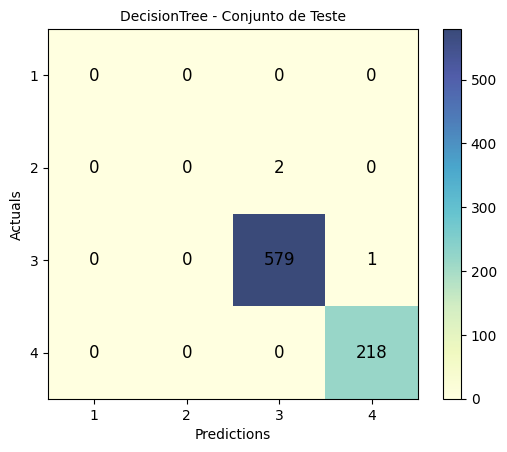


────────────────────────────────────────────────────────────────────────────────
Modelo: ExtraTrees
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         2
           3       0.99      0.99      0.99       580
           4       0.98      0.99      0.99       218

    accuracy                           0.99       800
   macro avg       0.49      0.50      0.49       800
weighted avg       0.99      0.99      0.99       800


Matriz de Confusão:
[[  0   0   0   0]
 [  0   0   2   0]
 [  0   0 576   4]
 [  0   0   2 216]]


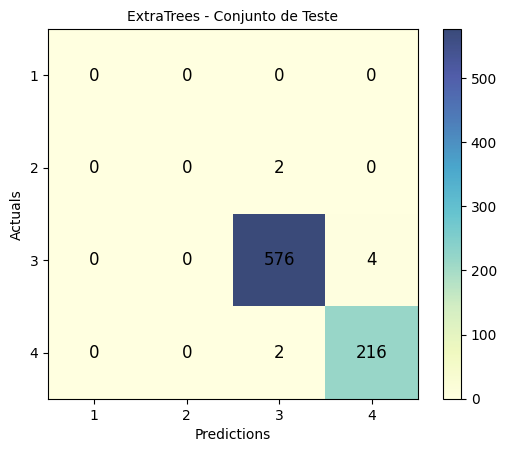


────────────────────────────────────────────────────────────────────────────────
Modelo: RandomForest
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         2
           3       0.99      1.00      1.00       580
           4       1.00      0.99      0.99       218

    accuracy                           0.99       800
   macro avg       0.50      0.50      0.50       800
weighted avg       0.99      0.99      0.99       800


Matriz de Confusão:
[[  0   0   0   0]
 [  0   0   2   0]
 [  0   0 579   1]
 [  0   0   2 216]]


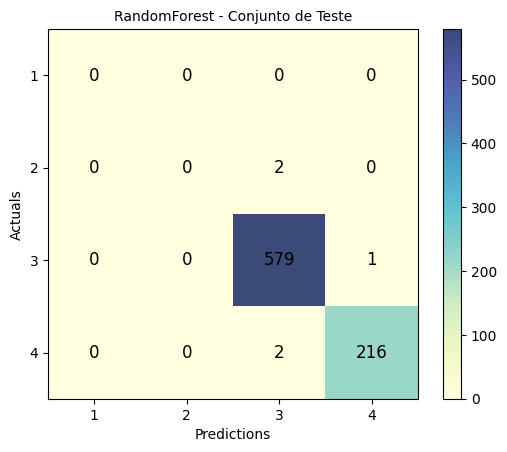


────────────────────────────────────────────────────────────────────────────────
Modelo: GaussianNB
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         2
           3       0.81      0.98      0.89       580
           4       0.89      0.39      0.54       218

    accuracy                           0.82       800
   macro avg       0.42      0.34      0.36       800
weighted avg       0.83      0.82      0.79       800


Matriz de Confusão:
[[  0   0   0   0]
 [  0   0   2   0]
 [  0   0 569  11]
 [  0   0 133  85]]


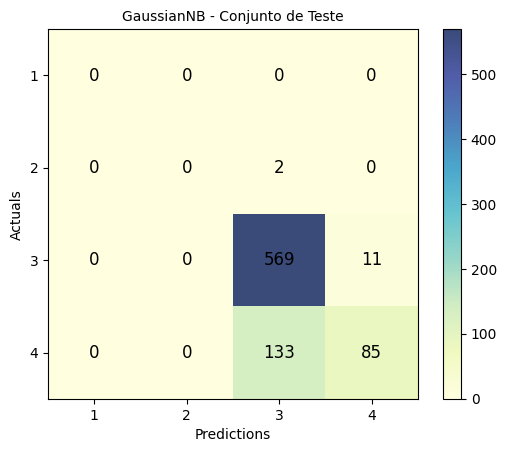


RELATÓRIO RESUMIDO - CONJUNTO DE TESTE
LogisticRegression   | Acc: 0.9975
KNeighbors           | Acc: 0.9337
SVC                  | Acc: 0.8413
DecisionTree         | Acc: 0.9962
ExtraTrees           | Acc: 0.9900
RandomForest         | Acc: 0.9938
GaussianNB           | Acc: 0.8175



In [ ]:
begin = 0
end = 800

fraction_datetimes = datetimes[begin:end]
fraction_datetimes_dt = datetimes_dt[begin:end]
fraction_temporal_features = temporal_features[begin:end]
fraction_routes_latency = historico_latencias[begin:end]
fraction_routes_label = rotas[begin:end]

X_fraction = np.hstack([fraction_temporal_features, fraction_routes_latency])
y_fraction = fraction_routes_label

pathIds = np.unique(y)
n_classes = len(historico_latencias[0])

fig = plt.figure(figsize=(12, 5))

for i in range(n_classes):
    pathId = i + 1

    propriedades = rotas[pathId]
    nome = propriedades["nome"]
    cor = propriedades["cor"]

    plt.plot(fraction_datetimes, fraction_routes_latency[:, i], label=f'Caminho {pathId}: {nome}', color=cor, linewidth=1.5)

step = max(1, len(fraction_datetimes) // 10)  # mostra +- 10 datas no eixo
plt.xticks(fraction_datetimes[::step], rotation=45)

plt.legend()
plt.xlabel('Data/Hora')
plt.ylabel('Latência (ms)')
plt.title('Latência ao longo do tempo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

test_results = evaluate_on_test(X_fraction, y_fraction, trained_pipelines, rotulos_dataset, binary_classification=binaryClassification, result_path=f'{pasta_resultados}')

[1 2 3 4]


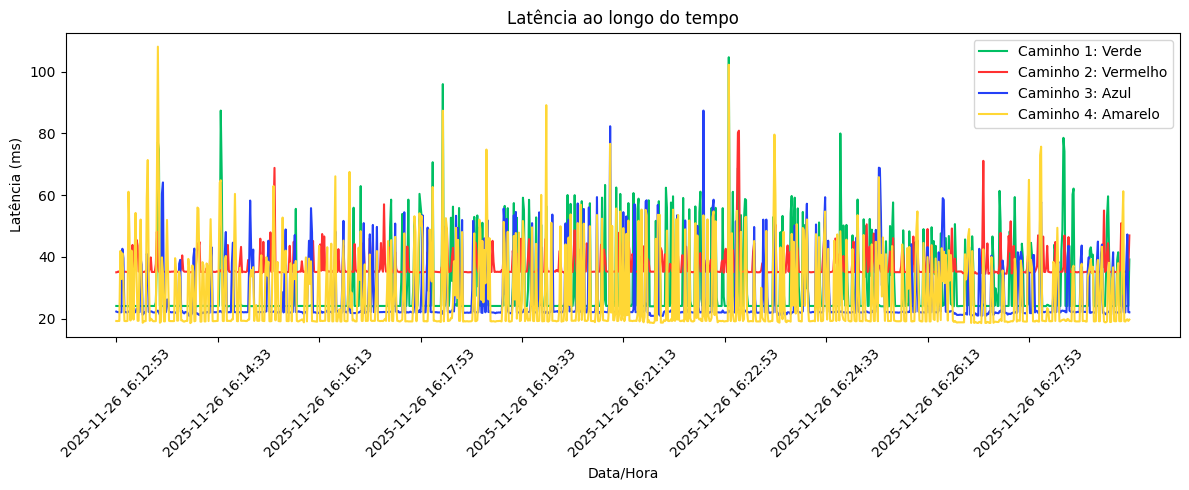

AVALIAÇÃO NO CONJUNTO DE TESTE (DADOS NÃO VISTOS)


────────────────────────────────────────────────────────────────────────────────
Modelo: LogisticRegression
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       1.00      0.99      1.00       134
           2       0.92      1.00      0.96        11
           3       1.00      0.99      1.00       232
           4       1.00      1.00      1.00       623

    accuracy                           1.00      1000
   macro avg       0.98      1.00      0.99      1000
weighted avg       1.00      1.00      1.00      1000


Matriz de Confusão:
[[133   1   0   0]
 [  0  11   0   0]
 [  0   0 230   2]
 [  0   0   0 623]]


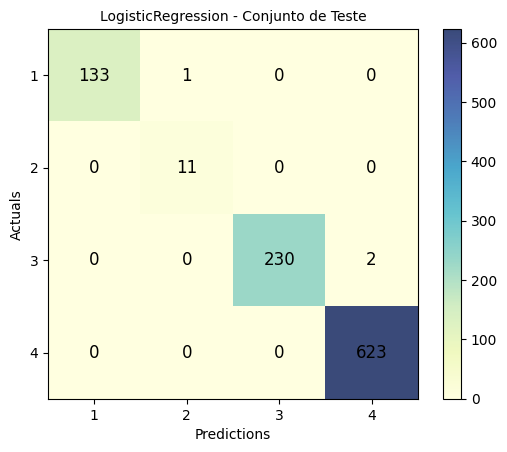


────────────────────────────────────────────────────────────────────────────────
Modelo: KNeighbors
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.98      0.90      0.93       134
           2       0.82      0.82      0.82        11
           3       0.94      0.91      0.92       232
           4       0.96      0.99      0.98       623

    accuracy                           0.96      1000
   macro avg       0.92      0.90      0.91      1000
weighted avg       0.96      0.96      0.96      1000


Matriz de Confusão:
[[120   1  11   2]
 [  2   9   0   0]
 [  0   1 210  21]
 [  1   0   3 619]]


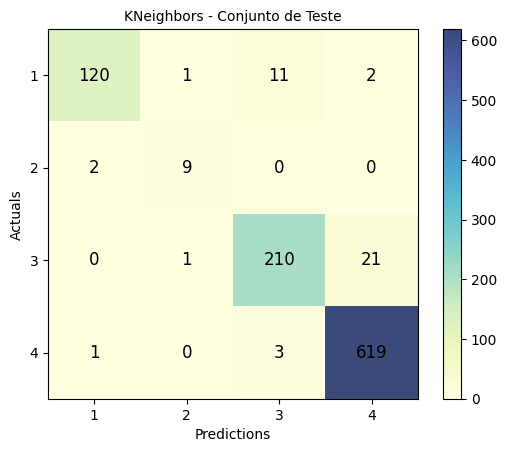


────────────────────────────────────────────────────────────────────────────────
Modelo: SVC
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       134
           2       0.00      0.00      0.00        11
           3       1.00      0.01      0.02       232
           4       0.62      1.00      0.77       623

    accuracy                           0.62      1000
   macro avg       0.41      0.25      0.20      1000
weighted avg       0.62      0.62      0.48      1000


Matriz de Confusão:
[[  0   0   0 134]
 [  0   0   0  11]
 [  0   0   2 230]
 [  0   0   0 623]]


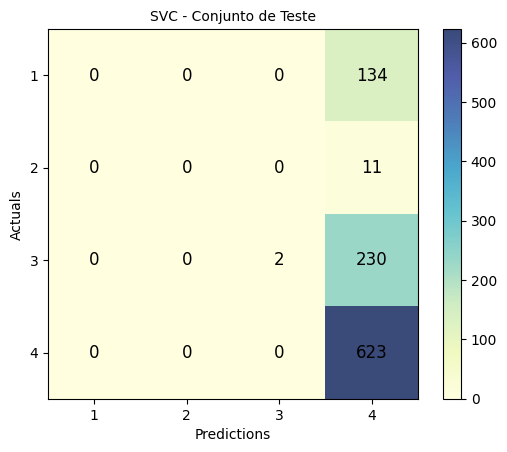


────────────────────────────────────────────────────────────────────────────────
Modelo: DecisionTree
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       1.00      0.98      0.99       134
           2       1.00      1.00      1.00        11
           3       0.99      1.00      1.00       232
           4       1.00      1.00      1.00       623

    accuracy                           1.00      1000
   macro avg       1.00      0.99      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Matriz de Confusão:
[[131   0   2   1]
 [  0  11   0   0]
 [  0   0 232   0]
 [  0   0   0 623]]


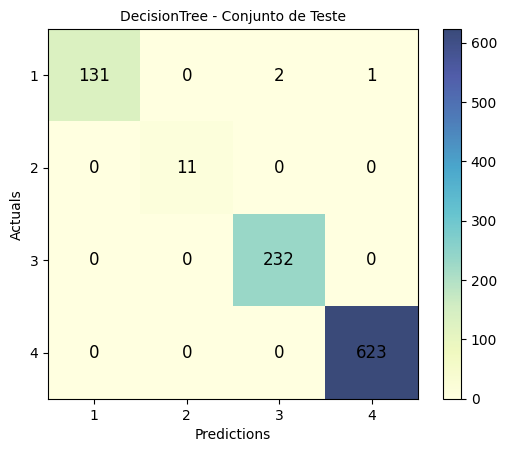


────────────────────────────────────────────────────────────────────────────────
Modelo: ExtraTrees
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.99      0.99      0.99       134
           2       0.91      0.91      0.91        11
           3       1.00      1.00      1.00       232
           4       1.00      1.00      1.00       623

    accuracy                           1.00      1000
   macro avg       0.97      0.98      0.97      1000
weighted avg       1.00      1.00      1.00      1000


Matriz de Confusão:
[[133   0   1   0]
 [  1  10   0   0]
 [  0   0 232   0]
 [  0   1   0 622]]


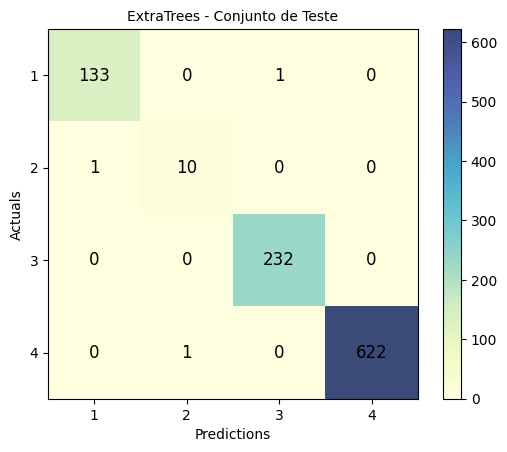


────────────────────────────────────────────────────────────────────────────────
Modelo: RandomForest
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       1.00      0.99      0.99       134
           2       1.00      1.00      1.00        11
           3       1.00      1.00      1.00       232
           4       1.00      1.00      1.00       623

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Matriz de Confusão:
[[132   0   1   1]
 [  0  11   0   0]
 [  0   0 232   0]
 [  0   0   0 623]]


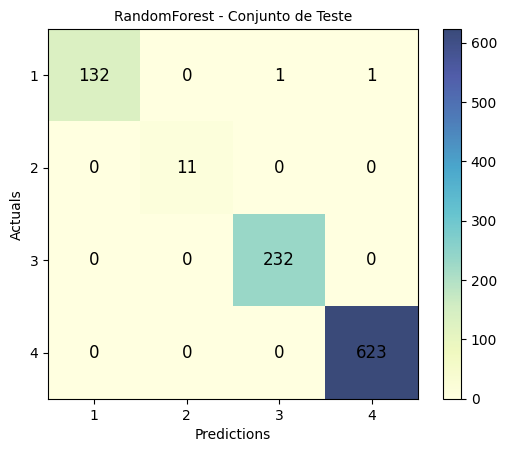


────────────────────────────────────────────────────────────────────────────────
Modelo: GaussianNB
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.16      0.95      0.28       134
           2       0.10      1.00      0.18        11
           3       0.89      0.07      0.14       232
           4       0.96      0.13      0.22       623

    accuracy                           0.23      1000
   macro avg       0.53      0.54      0.20      1000
weighted avg       0.83      0.23      0.21      1000


Matriz de Confusão:
[[127   5   2   0]
 [  0  11   0   0]
 [119  93  17   3]
 [539   5   0  79]]


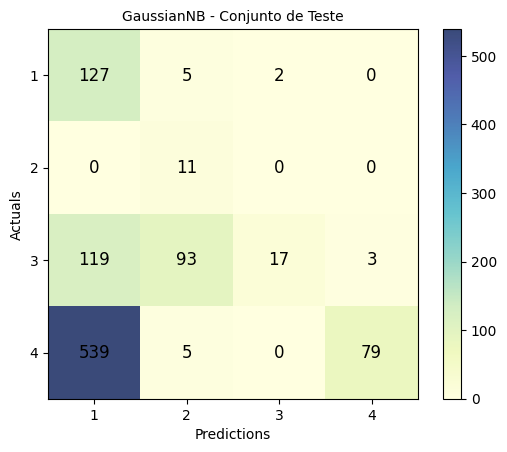


RELATÓRIO RESUMIDO - CONJUNTO DE TESTE
LogisticRegression   | Acc: 0.9970
KNeighbors           | Acc: 0.9580
SVC                  | Acc: 0.6250
DecisionTree         | Acc: 0.9970
ExtraTrees           | Acc: 0.9970
RandomForest         | Acc: 0.9980
GaussianNB           | Acc: 0.2340



In [64]:
begin = 1001
end = 2001

fraction_datetimes = datetimes[begin:end]
fraction_datetimes_dt = datetimes_dt[begin:end]
fraction_temporal_features = temporal_features[begin:end]
fraction_routes_latency = routes_latency[begin:end]
fraction_routes_label = routes_label[begin:end]

X_fraction = np.hstack([fraction_temporal_features, fraction_routes_latency])
y_fraction = fraction_routes_label

print(np.unique(y_fraction))

pathIds = np.unique(y)
n_classes = len(routes_latency[0])

fig = plt.figure(figsize=(12, 5))

for i in range(n_classes):
    pathId = i + 1

    propriedades = routes[pathId]
    nome = propriedades["nome"]
    cor = propriedades["cor"]

    plt.plot(fraction_datetimes, fraction_routes_latency[:, i], label=f'Caminho {pathId}: {nome}', color=cor, linewidth=1.5)

step = max(1, len(fraction_datetimes) // 10)  # mostra +- 10 datas no eixo
plt.xticks(fraction_datetimes[::step], rotation=45)

plt.legend()
plt.xlabel('Data/Hora')
plt.ylabel('Latência (ms)')
plt.title('Latência ao longo do tempo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

test_results = evaluate_on_test(X_fraction, y_fraction, trained_pipelines, class_labels, binary_classification=binaryClassification, result_path=f'{data_path}/results')